In [1]:
from skykatana import SkyMaskPipe
import matplotlib.pyplot as plt
from pathlib import Path
import lsdb      # if pixelating source catalogs in HATS format

# Quick intro or how to swing a Skykatana
-----------------
Starting from an input catalog of sources, a list of geometric shapes on the sky, or any healsparse map, ``Skykatana`` can create a pixelized mask in healsparse format, excluding areas due to various effects such as bright stars, patches with low depth, etc. It also allows to combine this mask with arbitrary regions defined by the user

Basic usage: 
* **build_footprint_mask(), build_patch_mask(), build_holes_mask(), etc.** are used to produce individual masks
* **combine_mask()** merge the maps create above to generate a final mask
* **plot()** can quickly visualize a mask by plotting randoms, make zooms and overplot stars
* **plot_moc()** can visualize a MOC version of a mask, with precise coordinate projections
* **makerans()** can generate randoms over a mask
* **apply()** can cut out sources outside of any given mask

When pixelating an input catalog of sources, ``Skykatana`` can use a pandas daframe, an astropy table (or any format readable by astropy), or a HATS catalog. In the latter case pixelization can be distributed across workers to deal with catalogs larger than available memory, such as LSST.

## Define inputs

In [3]:
BASEPATH = Path('../../skykatana_example_data/example_data/')

# Input HATS catalog (these are HSC galaxies)
HATSCAT = BASEPATH / 'hscx_minispring_gal/'

# Bright star regions of HSC
STARS_REGIONS     = BASEPATH / 'hsc_aux/stars_iband.parquet' 
BOX_STARS_REGIONS = BASEPATH / 'hsc_aux/starboxes_iband.parquet' 

# HSC patches and QA patch list ###################################### 
# See https://hsc-release.mtk.nao.ac.jp/schema/#pdr3.pdr3_wide.patch_qa
PATCH_FILE     = [BASEPATH / 'hsc_aux/tracts_patches_minispring.parquet']
QA_FILE        = BASEPATH / 'hsc_aux/patch_qa.csv'

# SFD dust extintion map (cut to the region covered by the example)
PROPMAP_FILE   = BASEPATH / 'hsc_aux/sfd_ebv_piece.fits'

# Extended sources to mask out
ELLIP_REGIONS = BASEPATH / 'hsc_aux/extended_sources.dat'

# User defined masks
USER_CIRCLE_REGIONS = BASEPATH / 'hsc_aux/user_circs.dat' 
USER_POLY_REGIONS   = BASEPATH / 'hsc_aux/user_polys.dat'

## 1. Create the pipeline and run! 
-----------

After SkyMaskPipe is instanciated, you can build masks (a.k.a. maps) due to various effects. Each of them is independent and can be run (or not) individually. Their results are **healsparse maps** we call `stages`, which stored within the class as:
* **`Footprint stage`** :: holds the footprint map created from the input catalog **[SkyMaskPipe.foot]**
* **`Patchmap stage`** :: holds the map created from HSC patches matching some criteria **[SkyMaskPipe.patchmap]**
* **`Properymap stage`** :: holds the map created from the intersection of multiple propery maps matching some criteria **[SkyMaskPipe.propmap]**
* **`Holemap stage`** :: holds the map created from circles & boxes due to bright stars HSC, to mask out **[SkyMaskPipe.holemap]**
* **`Extendedmap stage`** :: holds the map created from a list of elliptical sources to mask out **[SkyMaskPipe.extendedmap]**
* **`Usermap stage`** :: holds the footprint map created from user defined regions **[SkyMaskPipe.usermap]**

Then, all/some of these masks can be combined by `combine_mask()` into:
* **`Mask stage`** :: holds the **final** mask after combining the maps above **[SkyMaskPipe.mask]**   

In [3]:
mkp = SkyMaskPipe(order_out=15)
mkp.build_footprint_mask(sources=lsdb.open_catalog(HATSCAT))
mkp.build_patch_mask(patchfile=PATCH_FILE, qafile=QA_FILE)
mkp.build_holes_mask(star_regs=STARS_REGIONS, box_regs=BOX_STARS_REGIONS)
mkp.build_extended_mask(ellip_regs=ELLIP_REGIONS)
mkp.combine_mask()

BUILDING FOOTPRINT MAP >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- Pixelating HATS catalog
    Order :: 13
--- Footprint map area                    : 69.35790724770318
BUILDING PATCH MAP >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- Processing ../../skykatana_example_data/example_data/hsc_aux/tracts_patches_minispring.parquet
    Order :: 13
    Patches with QA                       : 3708
    Patches with QA fulfilling conditions : 2003
    Surviving patch pixels                : 1062650
--- Patch map area                        : 54.43575391135537
BUILDING BRIGHT STAR HOLES MAP >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- Pixelating circles from ../../skykatana_example_data/example_data/hsc_aux/stars_iband.parquet
    Order :: 15
    done
--- Pixelating boxes from ../../skykatana_example_data/example_data/hsc_aux/starboxes_iband.parquet
    Order :: 15
    done
--- Holes map area                        : 16.295306306474806
BUILDING EXTENDED MAP >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- P

In [13]:
# Use print() to display useful information
print(mkp)

foot           : nside_cov=16     nside_sparse=8192   valid_pix=1353948  area= 69.36 deg²  pix_size=  25.8"
patchmap       : nside_cov=16     nside_sparse=32768  valid_pix=17002400  area= 54.44 deg²  pix_size=   6.4"
propmap        : Not defined
holemap        : nside_cov=16     nside_sparse=32768  valid_pix=5089657  area= 16.30 deg²  pix_size=   6.4"
extendedmap    : nside_cov=16     nside_sparse=32768  valid_pix=168932   area=  0.54 deg²  pix_size=   6.4"
usermap        : Not defined
mask           : nside_cov=16     nside_sparse=32768  valid_pix=14333371  area= 45.89 deg²  pix_size=   6.4"


## 2. Generate randoms / Apply final mask to input catalog / Save pipeline to disk
---------

In [53]:
rands = mkp.makerans(stage='mask', nr=500_000)
rands[:5]

ra,dec
float64,float64
219.28153038024902,4.445927368000309
223.27601015567777,2.815690230070177
222.98188984394073,2.663239171986238
225.23537456989288,4.414291034085433
226.48453831672668,1.1807273012220032


In [54]:
# You can generate randoms over any stage
rands_in_holes = mkp.makerans(stage='holemap', nr=100_000)
rands_in_holes[:5]

ra,dec
float64,float64
223.07317078113556,3.771877220413049
226.80505156517026,-1.3279941899664784
214.30637598037717,4.0190136507834024
215.4866337776184,-2.322859599679479
222.90331184864044,-2.0069651501179306


In [21]:
# Use apply() to return a catalog filtered by any mask stage
import lsdb
cat = lsdb.read_hats(HATSCAT, columns=['ra','dec']).compute()
srcs_masked = mkp.apply(stage='mask', cat=cat, columns=['ra','dec'])

6023508 sources within mask


In [10]:
# Save SkyMaskPipe object to disk
mkp.write(BASEPATH / 'minispring.maskpipe')

../example_data/minispring.maskpipe saved to disk


## 3. Explore some plots
-------------------

The **`plot()`** method is suitable for very fast visualizations by plotting random (ra,dec) sources over the given stage 

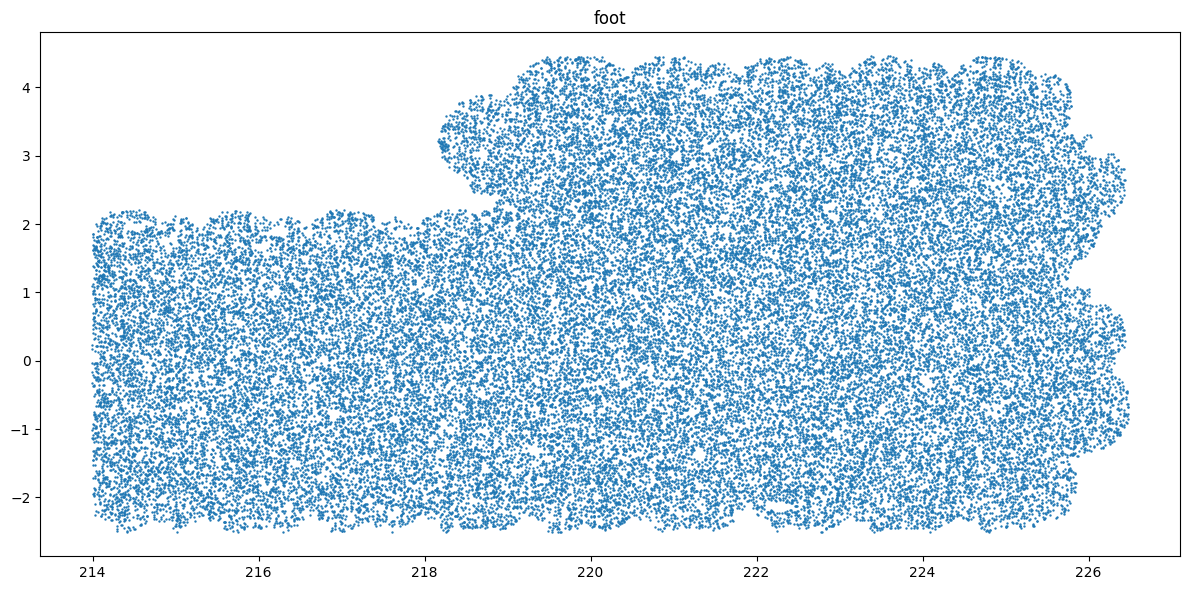

In [5]:
# Plot the footprint
mkp.plot(stage='foot')

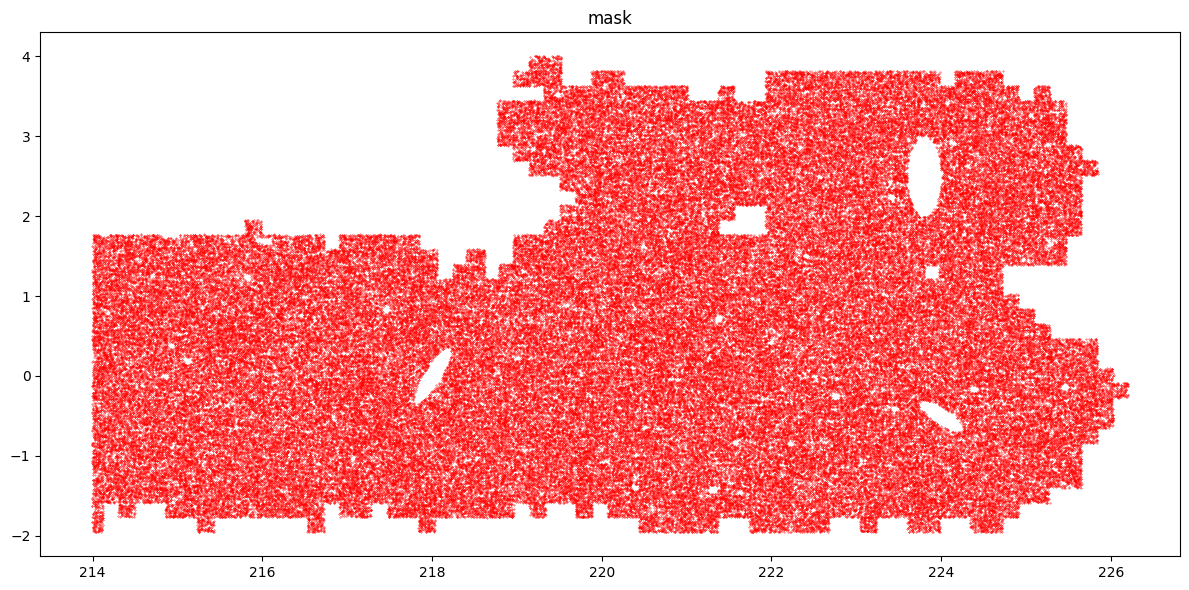

In [6]:
# Plot the final mask, 200k randoms
mkp.plot(stage='mask', nr=200_000, s=0.09, color='r')

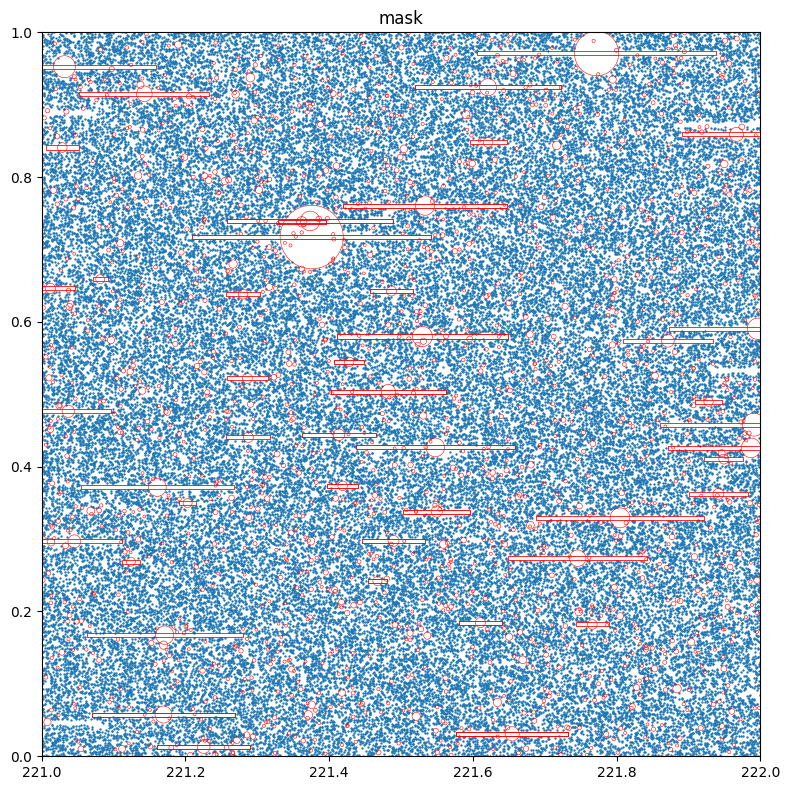

In [7]:
# Plot a zoom of the final mask, include circles and boxes associated to stars masked out
mkp.plot(stage='mask', nr=4_000_000, figsize=[8,8], xwin=[221,222], ywin=[0,1], plot_stars=True, plot_boxes=True)

-----------------------
The **`plot_moc()`** method is suitable for accurrate visualizations in a WCS axes with suitable projections

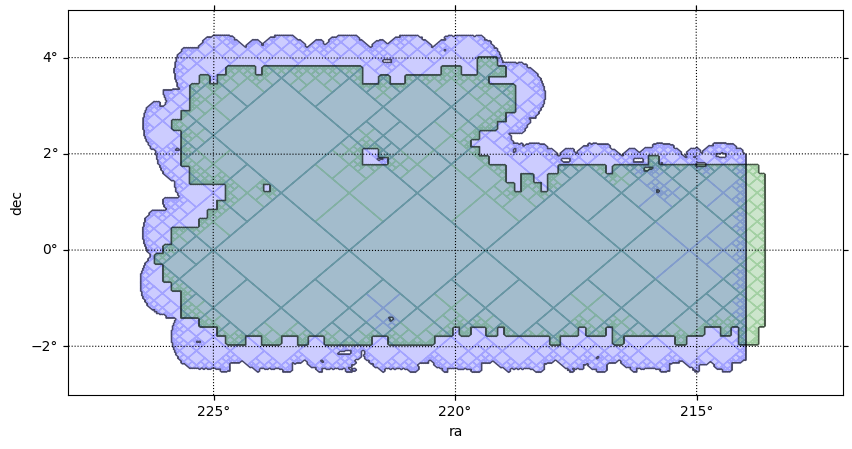

In [4]:
# Visualize stages by plotting their MOC in a WCS axes
import astropy.units as u
from astropy.coordinates import SkyCoord

center = SkyCoord(220*u.deg, 1*u.deg)   # center of plot
fov    = 8 * u.deg                      # field of view
fig, ax, wcs = mkp.plot_moc(stage='foot', center=center, fov=fov, color='b')   # MOC of the footprint mask
fig, ax, wcs = mkp.plot_moc(stage='patchmap', ax=ax, wcs=wcs, color='g')       # MOC of the patch mask

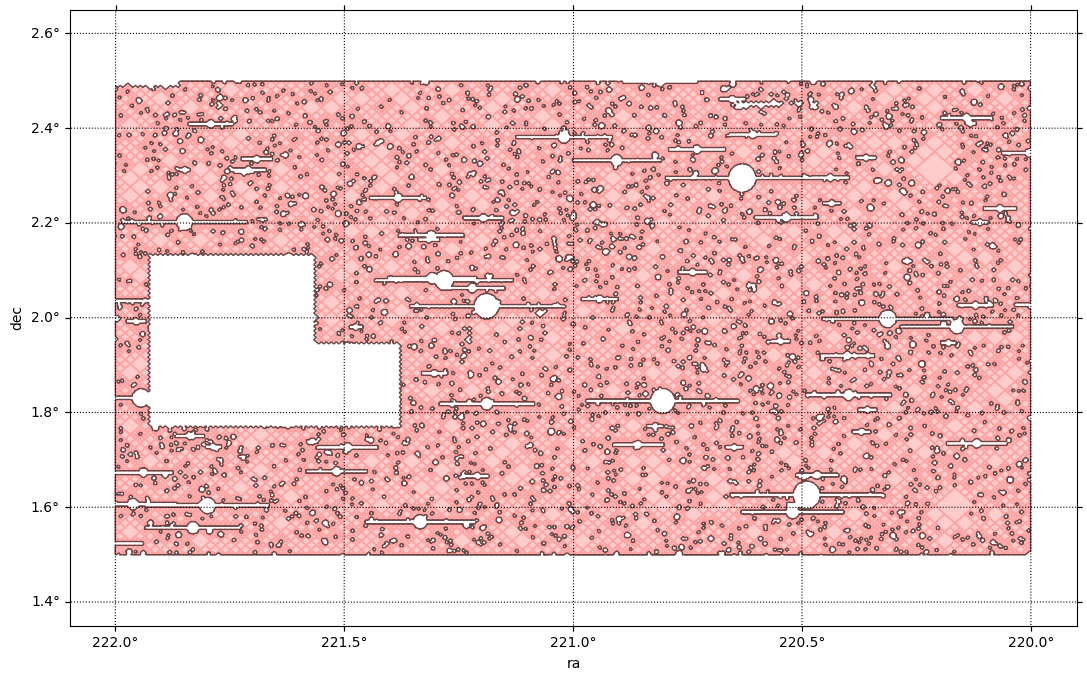

In [10]:
# Now plot a zoom of a MOC. When zooming over a MOC, millions of high order pixels can show up and slow plotting.
# Use clipra/clipdec to only process pixels within the window you are displaying
center = SkyCoord(221*u.deg, 2*u.deg)    # center of plot
fov    = [2.2*u.deg, 1.3*u.deg]          # field of view 
clipra = [220, 222]                      # only process pixels within a box
clipdec = [1.5, 2.5]                     # only process pixels within a box
fig, ax, wcs = mkp.plot_moc(stage='mask',  center=center, fov=fov,  color='r', clipra=clipra, clipdec=clipdec, figsize=[13,8])

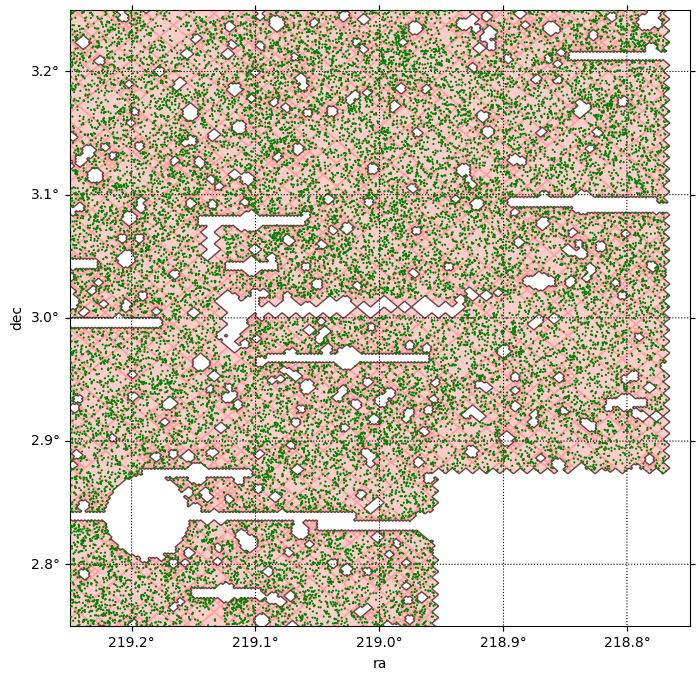

In [32]:
# Now plot another zoom and overlay a catalog sources
center = SkyCoord(219*u.deg, 3*u.deg)    # center of plot
fov    = [0.5*u.deg, 0.5*u.deg]          # field of view 
clipra = [218.5, 219.3]                  # only process pixels within a box
clipdec = [2.7, 3.5]                     # only process pixels within a box
fig, ax, wcs = mkp.plot_moc(stage='mask',  center=center, fov=fov,  color='r', alpha=0.2, clipra=clipra, clipdec=clipdec, figsize=[8,8])
fig, ax, wcs = mkp.plot_srcs(srcs_masked['ra'], srcs_masked['dec'], ax=ax, wcs=wcs, s=10, alpha=1, color='g', zorder=10)

## 4. Now add a user-defined mask
-------------

In [33]:
# Our user defined regions are just a couple of circles and some boxes
mkp.build_user_mask(circ_uregs=USER_CIRCLE_REGIONS, poly_uregs=USER_POLY_REGIONS)
mkp.combine_mask(apply_extendedmap=False, apply_usermap=True)        # By default apply_usermap=False

BUILDING USER DEFINED MAP >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- Pixelating circles from ../../skykatana_example_data/example_data/hsc_aux/user_circs.dat
    Order :: 15
    done
--- Pixelating polygons from ../../skykatana_example_data/example_data/hsc_aux/user_polys.dat
    Order :: 15
--- User map area                         : 1.2559277140625398
COMBINING MAPS >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- base map upgraded to: 15
--- Combined map area                     : 1.1014320366880248


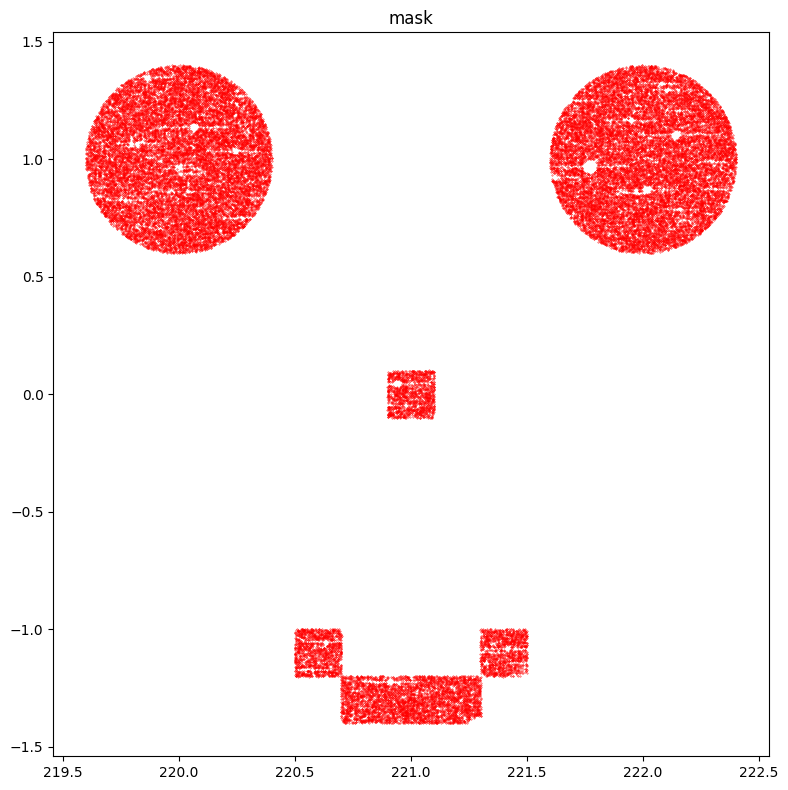

In [34]:
mkp.plot(stage='mask', nr=50_000, s=0.09, color='r', figsize=[8,8])

## 5. Apply custom HSC patch filtering
----------

In [35]:
mkp_custom = SkyMaskPipe()
mkp_custom.build_footprint_mask(sources=lsdb.open_catalog(HATSCAT))
mkp_custom.build_patch_mask(patchfile=PATCH_FILE, qafile=QA_FILE, filt='(imag_psf_depth>26.3)')
mkp_custom.combine_mask(apply_holemap=False, apply_extendedmap=False)

BUILDING FOOTPRINT MAP >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- Pixelating HATS catalog
    Order :: 13
--- Footprint map area                    : 69.35790724770318
BUILDING PATCH MAP >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- Processing ../../skykatana_example_data/example_data/hsc_aux/tracts_patches_minispring.parquet
    Order :: 13
    Patches with QA                       : 3708
    Patches with QA fulfilling conditions : 1167
    Surviving patch pixels                : 633006
--- Patch map area                        : 32.426630443148184
COMBINING MAPS >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- base map upgraded to: 15
--- patchmap order upgraded to: 15
--- Combined map area                     : 31.036294211173313


In [36]:
# Recombine the final mask again without the usermap of the "smile face" above
mkp.combine_mask()    # By default apply_usermap=False

COMBINING MAPS >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- base map upgraded to: 15
--- Combined map area                     : 45.8904540815507


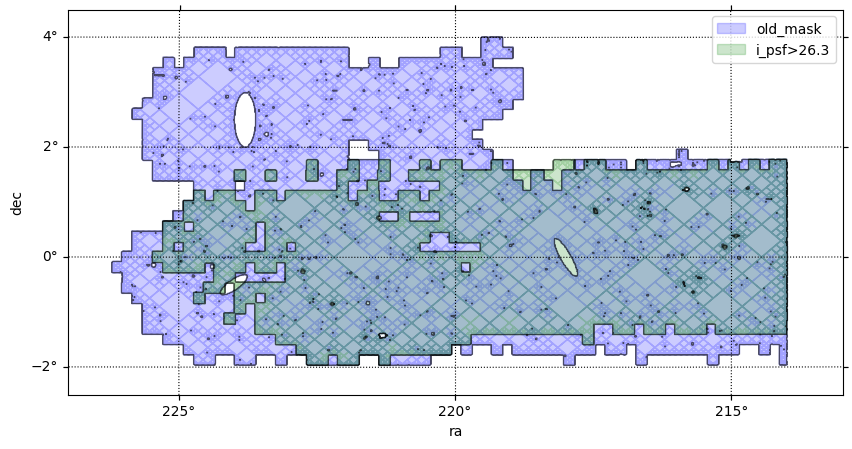

In [47]:
# Visualize stages by plotting their MOC in a WCS axes
import astropy.units as u
from astropy.coordinates import SkyCoord

center = SkyCoord(220*u.deg, 1*u.deg)   # center of plot
fov    = 7 * u.deg                      # field of view
fig, ax, wcs = mkp.plot_moc(stage='mask', center=center, fov=fov, color='b', label='old_mask')
fig, ax, wcs = mkp_custom.plot_moc(stage='mask', ax=ax, wcs=wcs, color='g', label='i_psf>26.3')
plt.legend();

* Note setting `filt=None` applies no filtering and therefore all patches will be pixelized into the patchmap.
* Note leaving `filt` unspecified will use the default filtering recipe, which impose minimum values on gri depths in order to select a more uniform coverage :: (gmag_psf_depth>26.2) and (rmag_psf_depth>25.9) and (imag_psf_depth>25.7)

## 6. Apply property maps
----------

While patches are geometric constructions specific to HSC, in general you can also restrict to areas of the sky meeting certain conditions if you have healsparse propery maps available.

In [48]:
# The map file here contains a small region of the dust extinction map of Schlegel, Finkbeiner & Davies in healsparse format. 
# This (arbitrary) cut will discard areas with very high extinction
mkp.build_propmap_mask(prop_maps=PROPMAP_FILE,thresholds=1.3,comparisons='lt')
mkp.combine_mask(apply_propmap=True)    # By default apply_propmap=False

BUILDING PROPERTY MAP >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- Processing ../../skykatana_example_data/example_data/hsc_aux/sfd_ebv_piece.fits
--- Property map area                     : 113.86116591708016
COMBINING MAPS >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- base map upgraded to: 15
--- propmap order upgraded to: 15
--- Combined map area                     : 40.5307235313453


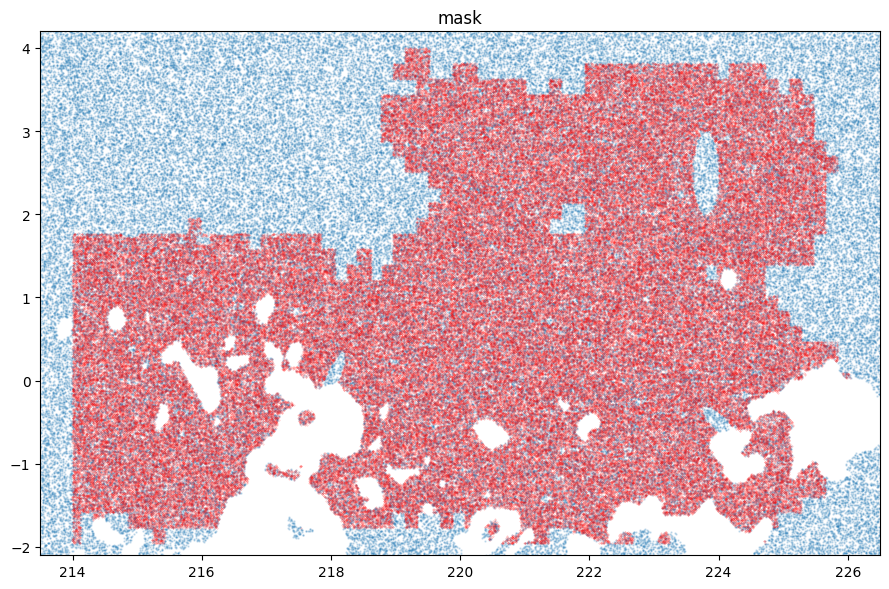

In [49]:
# Overlay the SFD extincion mask and the new combined final mask
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=[9,6])
mkp.plot(stage='propmap', nr=200_000, alpha=0.2, ywin=[-2.1,4.2], xwin=[213.5, 226.5], ax=ax)
mkp.plot(stage='mask', nr=200_000, s=0.09, color='r', alpha=0.3 , ax=ax)

## 7. Using other stages as footprint

The footprint is meant to be the positive area of sky from which you subtract other areas for various reasons when combining stages into a final mask. The footprint can be made from:
* Discrete sources: for example using **`build_footprint_mask()`**
* Geometrical regions: boxes, circles, elipses, etc., for example using **`build_user_mask()`**
* A healsparse property map: for example using **`build_propmap_mask()`**

You can use any stage as a "footprint" using the **`footprint_override`** keyword

In [58]:
mkp = SkyMaskPipe(order_out=15)
mkp.build_propmap_mask(prop_maps=PROPMAP_FILE,thresholds=0.8,comparisons='lt')
mkp.build_holes_mask(star_regs=STARS_REGIONS, box_regs=BOX_STARS_REGIONS)
mkp.combine_mask(footprint_override=mkp.propmap, apply_holemap=True, apply_patchmap=False, apply_extendedmap=False)

BUILDING PROPERTY MAP >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- Processing ../../skykatana_example_data/example_data/hsc_aux/sfd_ebv_piece.fits
--- Property map area                     : 74.60615630404928
BUILDING BRIGHT STAR HOLES MAP >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- Pixelating circles from ../../skykatana_example_data/example_data/hsc_aux/stars_iband.parquet
    Order :: 15
    done
--- Pixelating boxes from ../../skykatana_example_data/example_data/hsc_aux/starboxes_iband.parquet
    Order :: 15
    done
--- Holes map area                        : 16.295306306474806
COMBINING MAPS >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- base map upgraded to: 15
--- Combined map area                     : 66.2747779990494


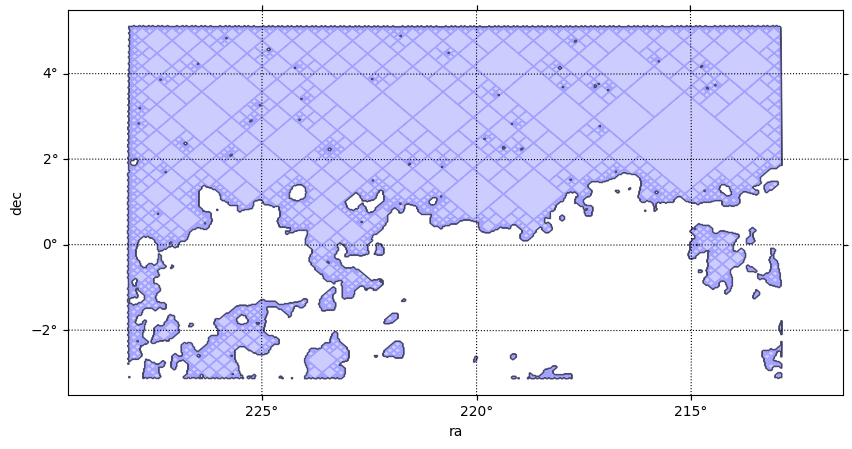

In [59]:
# Plot the combined mask MOC in a WCS axes
import astropy.units as u
from astropy.coordinates import SkyCoord

center = SkyCoord(220.5*u.deg, 1*u.deg)   # center of plot
fov    = 9 * u.deg                      # field of view
fig, ax, wcs = mkp.plot_moc(stage='mask', center=center, fov=fov, color='b')

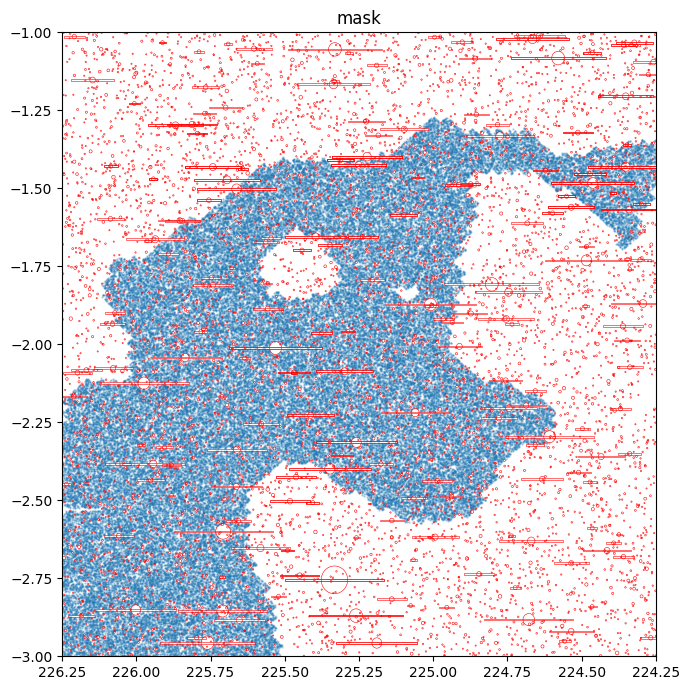

In [57]:
# Make a zoom with randoms over the duck in the lower left corner
mkp.plot(stage='mask', nr=4_000_000, xwin=[224.25,226.25], ywin=[-3.0,-1], plot_stars=True, plot_boxes=True, figsize=[7,7], alpha=0.3)
plt.gca().invert_xaxis()